In [1]:
import os
import random
import time
import logging
import warnings

import cv2
import numpy as np
import pandas as pd

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# =============================================================================
# CONFIG
# =============================================================================

class CFG:

    CSV_PATH = (
        "/kaggle/input/datasets/kmader/rsna-bone-age/"
        "boneage-training-dataset.csv"
    )

    IMAGE_DIR = (
        "/kaggle/input/datasets/kmader/rsna-bone-age/"
        "boneage-training-dataset/boneage-training-dataset"
    )

    PROCESSED_DIR = "/kaggle/working/processed_512"

IMAGE_SIZE = 512

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

LABEL_MEAN = 127.3
LABEL_STD  = 41.2

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-7s  %(message)s",
    datefmt="%H:%M:%S",
)

log = logging.getLogger("bone_age")

print("Imports + CFG loaded")

Imports + CFG loaded


In [6]:
# =============================================================================
# HELPERS
# =============================================================================

def normalise_label(age_months: float) -> float:
    return (age_months - LABEL_MEAN) / LABEL_STD


def load_as_float(path: str) -> np.ndarray:

    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise IOError(f"Cannot read image: {path}")

    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    if img.dtype == np.uint16:
        img = img.astype(np.float32) / 65535.0
    else:
        img = img.astype(np.float32) / 255.0

    return img


def apply_clahe(img: np.ndarray):

    img_u8 = (img * 255).astype(np.uint8)

    clahe = cv2.createCLAHE(
        clipLimit=1.5,
        tileGridSize=(8, 8)
    )

    result = clahe.apply(img_u8)

    return result.astype(np.float32) / 255.0


def crop_hand_roi(img: np.ndarray):

    h, w = img.shape

    img_u8 = (img * 255).astype(np.uint8)

    _, binary = cv2.threshold(
        img_u8,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (25, 25)
    )

    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_CLOSE,
        kernel
    )

    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return img

    largest = max(contours, key=cv2.contourArea)

    x, y, rw, rh = cv2.boundingRect(largest)

    pad_x = int(0.04 * rw)
    pad_y = int(0.04 * rh)

    x1 = max(0, x - pad_x)
    y1 = max(0, y - pad_y)

    x2 = min(w, x + rw + pad_x)
    y2 = min(h, y + rh + pad_y)

    return img[y1:y2, x1:x2]


def letterbox_resize(img: np.ndarray):

    h, w = img.shape

    scale = IMAGE_SIZE / max(h, w)

    new_h = int(h * scale)
    new_w = int(w * scale)

    resized = cv2.resize(
        img,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA
    )

    canvas = np.zeros(
        (IMAGE_SIZE, IMAGE_SIZE),
        dtype=np.float32
    )

    top = (IMAGE_SIZE - new_h) // 2
    left = (IMAGE_SIZE - new_w) // 2

    canvas[
        top:top+new_h,
        left:left+new_w
    ] = resized

    return canvas


def to_3channel(img: np.ndarray):

    return np.stack([img, img, img], axis=-1)


def preprocess_image(path: str):

    img = load_as_float(path)

    img = apply_clahe(img)

    img = crop_hand_roi(img)

    img = letterbox_resize(img)

    img = to_3channel(img)

    return img


# =============================================================================
# VERIFY DATASET
# =============================================================================

def verify_dataset(csv_path, image_dir):

    df = pd.read_csv(csv_path)

    df.columns = [
        c.strip().lower()
        for c in df.columns
    ]

    valid = []

    for _, row in df.iterrows():

        path = os.path.join(
            image_dir,
            f"{int(row['id'])}.png"
        )

        if os.path.exists(path):
            valid.append(row)

    clean = pd.DataFrame(valid)

    log.info(f"Valid samples: {len(clean)}")

    return clean.reset_index(drop=True)


# =============================================================================
# PREPROCESS + SAVE
# =============================================================================

def preprocess_and_save(
    df,
    image_dir,
    output_dir
):

    os.makedirs(output_dir, exist_ok=True)

    errors = 0
    skipped = 0

    log.info(f"Offline preprocessing → {output_dir}")

    t0 = time.time()

    for i, row in df.iterrows():

        img_id = int(row["id"])

        src = os.path.join(
            image_dir,
            f"{img_id}.png"
        )

        dst = os.path.join(
            output_dir,
            f"{img_id}.npy"
        )

        if os.path.exists(dst):
            skipped += 1
            continue

        try:

            arr = preprocess_image(src)

            arr_u8 = (arr * 255).astype(np.uint8)

            np.save(dst, arr_u8)

        except Exception as e:

            log.error(f"Failed [{img_id}]: {e}")

            errors += 1

        if (i + 1) % 500 == 0:

            elapsed = time.time() - t0

            log.info(
                f"{i+1}/{len(df)} images "
                f"({elapsed:.0f}s elapsed)"
            )

    log.info(
        f"Done. "
        f"Skipped={skipped} "
        f"Errors={errors} "
        f"Total time={time.time()-t0:.1f}s"
    )

print("Functions loaded successfully")

Functions loaded successfully


In [4]:
print(CFG.CSV_PATH)

print(CFG.IMAGE_DIR)

print("\nCSV Exists:")
print(os.path.exists(CFG.CSV_PATH))

print("\nImage Dir Exists:")
print(os.path.exists(CFG.IMAGE_DIR))

print("\nTotal Images:")
print(len(os.listdir(CFG.IMAGE_DIR)))

df = verify_dataset(
    CFG.CSV_PATH,
    CFG.IMAGE_DIR
)

print("\nValid Samples:")
print(len(df))

/kaggle/input/datasets/kmader/rsna-bone-age/boneage-training-dataset.csv
/kaggle/input/datasets/kmader/rsna-bone-age/boneage-training-dataset/boneage-training-dataset

CSV Exists:
True

Image Dir Exists:
True

Total Images:
12611


07:47:36  INFO     Valid samples: 12611



Valid Samples:
12611


In [ ]:
preprocess_and_save(
    df,
    CFG.IMAGE_DIR,
    CFG.PROCESSED_DIR
)

07:47:43  INFO     Offline preprocessing → /kaggle/working/processed_512
07:49:17  INFO     500/12611 images (93s elapsed)
07:50:13  INFO     1000/12611 images (150s elapsed)
07:51:00  INFO     1500/12611 images (196s elapsed)
07:51:49  INFO     2000/12611 images (246s elapsed)
07:52:45  INFO     2500/12611 images (302s elapsed)
07:53:45  INFO     3000/12611 images (362s elapsed)
07:54:46  INFO     3500/12611 images (422s elapsed)
07:55:45  INFO     4000/12611 images (481s elapsed)
07:56:49  INFO     4500/12611 images (545s elapsed)
07:57:50  INFO     5000/12611 images (606s elapsed)
07:58:51  INFO     5500/12611 images (668s elapsed)
07:59:53  INFO     6000/12611 images (730s elapsed)
08:00:54  INFO     6500/12611 images (791s elapsed)
08:01:57  INFO     7000/12611 images (854s elapsed)
08:02:57  INFO     7500/12611 images (914s elapsed)
08:03:59  INFO     8000/12611 images (975s elapsed)
08:05:00  INFO     8500/12611 images (1037s elapsed)
08:06:02  INFO     9000/12611 images (1099s 

In [13]:
import random

sample_files = random.sample(
    os.listdir(CFG.PROCESSED_DIR),
    5
)

print(f"{'File':>12}  {'Shape':>16}  {'Dtype':>10}")

print("-" * 45)

for fname in sample_files:

    arr = np.load(
        os.path.join(CFG.PROCESSED_DIR, fname)
    )

    print(
        f"{fname:>12}  "
        f"{str(arr.shape):>16}  "
        f"{str(arr.dtype):>10}"
    )

        File             Shape       Dtype
---------------------------------------------
    3772.npy     (512, 512, 3)       uint8
    9131.npy     (512, 512, 3)       uint8
   13206.npy     (512, 512, 3)       uint8
   11096.npy     (512, 512, 3)       uint8
    7140.npy     (512, 512, 3)       uint8


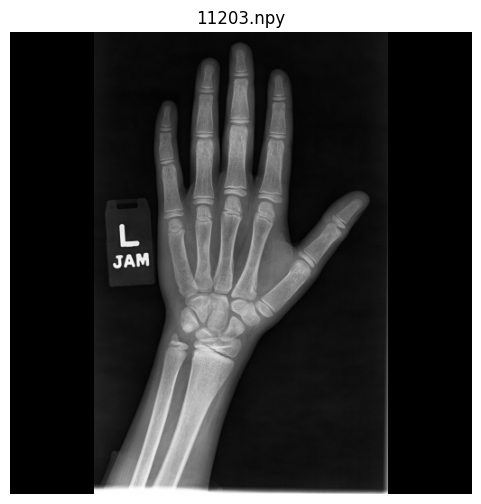

In [14]:
sample = random.choice(
    os.listdir(CFG.PROCESSED_DIR)
)

arr = np.load(
    os.path.join(CFG.PROCESSED_DIR, sample)
)

plt.figure(figsize=(6,6))

plt.imshow(arr)

plt.title(sample)

plt.axis("off")

plt.show()